In [119]:
from langgraph.graph import StateGraph, END, MessagesState
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_tavily import TavilySearch
from langchain.schema import Document
from typing import List
import os

In [120]:
# from langchain_aws import ChatBedrockConverse, BedrockEmbeddings

# embedding_model = BedrockEmbeddings(model_id="cohere.embed-english-v3")

In [135]:
#!pip install langchain-cohere

In [140]:
import getpass
import os

os.environ["COHERE_API_KEY"] = getpass.getpass()

 ········


In [162]:
from langchain_cohere import ChatCohere
from langchain_core.messages import HumanMessage

llm = ChatCohere()
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'id': '2e41b07b-0440-4ab6-8822-b1d880d254bf', 'finish_reason': 'COMPLETE', 'content': 'Hello! How can I assist you today?', 'token_count': {'input_tokens': 496.0, 'output_tokens': 11.0}}, response_metadata={'id': '2e41b07b-0440-4ab6-8822-b1d880d254bf', 'finish_reason': 'COMPLETE', 'content': 'Hello! How can I assist you today?', 'token_count': {'input_tokens': 496.0, 'output_tokens': 11.0}}, id='run--13ced97f-5b5b-4dd8-8fdd-61df345870b2-0', usage_metadata={'input_tokens': 496, 'output_tokens': 11, 'total_tokens': 507})

In [142]:
from langchain_cohere import CohereEmbeddings

embeddings = CohereEmbeddings(
    model="embed-english-v3.0",
)

In [145]:
embeddings.embed_query("Hi")[0:10]

[0.03366089,
 -0.031204224,
 -0.015899658,
 -0.06854248,
 -0.030059814,
 -0.021133423,
 -0.010231018,
 0.016403198,
 0.029312134,
 0.050964355]

In [121]:
# # 1. Load and index PDF
# loader = PyPDFLoader("AgenticHybridRAG.pdf")
# docs = loader.load()
# splitter = RecursiveCharacterTextSplitter(chunk_size=1000, 
#                                           chunk_overlap=200,
#                                           separators=["\n\n", "\n", ".", " ", ""])
# chunks1 = splitter.split_documents(docs)

In [146]:
# 2. Load and index PDF
loader = PyPDFLoader("prompt engineering.pdf")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, 
                                          chunk_overlap=200,
                                          separators=["\n\n", "\n", ".", " ", ""])
chunks = splitter.split_documents(docs)

In [147]:
# chunks = chunks1 + chunks2

In [148]:
chunks

[Document(metadata={'producer': 'Skia/PDF m139', 'creator': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/139.0.0.0 Safari/537.36', 'creationdate': '2025-10-29T06:23:02+00:00', 'title': "Prompt Engineering | Lil'Log", 'moddate': '2025-10-29T06:23:02+00:00', 'source': 'prompt engineering.pdf', 'total_pages': 17, 'page': 0, 'page_label': '1'}, page_content='Posts Archive Search Tags FAQ\nPrompt Engineering\nDate: March 15, 2023 | Estimated Reading Time: 21 min | Author: Lilian Weng\nTable of Contents\nPrompt Engineering, also known as In-Context Prompting, refers to methods for how to\ncommunicate with LLM to steer its behavior for desired outcomes without updating the\nmodel weights. It is an empirical science and the eﬀect of prompt engineering methods can\nvary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so\nnothing with Cloze tests, image gen

In [128]:
len(chunks)

42

In [149]:
# Using the previously stored vector db's 
FAISS_PATH = './Research Papers'
if os.path.exists(FAISS_PATH):
    research_db = FAISS.load_local(
        FAISS_PATH,
        embeddings,
        allow_dangerous_deserialization=True
    )
    print("Loaded existing FAISS index")
else:
    research_db = FAISS.from_documents(
        chunks,
        embeddings,
    )
    research_db.save_local(FAISS_PATH)
    print("Created and saved new FAISS index")


Created and saved new FAISS index


In [87]:
# llm = ChatBedrockConverse(model_id = "cohere.command-r-plus-v1:0")
# #llm.invoke("Hi").content


In [150]:
### Retrieval Grader

from langchain_core.prompts import ChatPromptTemplate

from pydantic import BaseModel, Field


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score:str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [151]:
# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)


In [152]:
retriever = research_db.as_retriever()

In [153]:
question = "prompt engineering techniques "
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
doc_txt

"[My personal spicy take] In my opinion, some prompt engineering papers are not worthy 8\npages long, since those tricks can be explained in one or a few sentences and the rest is all\nabout benchmarking. An easy-to-use and shared benchmark infrastructure should be more\nbeneﬁcial to the community. Iterative prompting or external tool use would not be trivial to\nset up. Also non-trivial to align the whole research community to adopt it.\nBasic Prompting\nZero-shot and few-shot learning are two most basic approaches for prompting the model,\npioneered by many LLM papers and commonly used for benchmarking LLM performance.\nZero-Shot\nZero-shot learning is to simply feed the task text to the model and ask for results.\n(All the sentiment analysis examples are from SST-2)\nText: i'll bet the video game is a lot more fun than the film.\nSentiment:\n10/29/25, 6:23 AM Prompt Engineering | Lil'Log\nhttps://lilianweng.github.io/posts/2023-03-15-prompt-engineering/ 1/17"

In [154]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

In [155]:
retrieval_grader = grade_prompt | structured_llm_grader

In [156]:
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [234]:
from langchain_core.prompts import ChatPromptTemplate

qa_system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n\n"
    "Context: {context}"
)

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", qa_system_prompt),
        ("human", "Question: {question} \nAnswer:"),
    ]
)

In [235]:
rag_prompt.pretty_print()

================================ System Message ================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.

Context: {context}

================================ Human Message =================================

Question: {question} 
Answer:


In [159]:
from langchain_core.output_parsers import StrOutputParser

In [160]:
 #Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = rag_prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Prompt engineering techniques include zero-shot and few-shot learning, which are basic approaches for steering language models without updating their weights. These methods involve feeding task-specific text to the model and asking for results, with the goal of achieving desired outcomes through alignment and model steerability. The effectiveness of these techniques varies among models, requiring experimentation and heuristics.


In [163]:
# ### Question Re-writer
# llm = ChatBedrockConverse(model_id = "cohere.command-r-plus-v1:0")
# #llm.invoke("Hi").content

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'**Improved Question:** What are the best practices and techniques for effective prompt engineering in AI and machine learning models?  \n\n**Rationale:** The improved question is more specific and actionable, focusing on practical techniques and best practices, which aligns better with the intent of learning about prompt engineering. It also broadens the scope to include AI and machine learning models, making it more relevant for web search results.'

In [169]:
import getpass
import os

#if not os.environ.get("TAVILY_API_KEY"):
os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key:\n")

Tavily API key:
 ········


In [180]:
### Web Search Tool

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    include_raw_content=True,
    # include_images=False,
    # include_image_descriptions=False,
    search_depth="advanced",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [228]:
docs =web_search_tool.invoke("What is f=ma?")

In [222]:
# Assuming 'docs' is the single top-level dictionary
results_list = docs.get('results', [])

# Iterate directly over the list of result dictionaries
for result in results_list:
    # Access the 'content' key directly from the current result dictionary
    print(result.get('content'))

Newton's second law of motion describes the relationship between an object's mass and the amount of force needed to accelerate it. Newton's second law is often stated as F=ma, which means the force (F) acting on an object is equal to the mass (m) of an object times its acceleration (a). This means the more mass an object has, the more force you need to accelerate it. And the greater the force, the greater the object's acceleration.

Posted on October 17, 2011 at 5:50 pm

Categories: [...] Smithsonian National Air and Space Museum

Share

 Twitter
 Facebook

# Ask an Explainer

Q:

## What does "F=ma" mean in Newton's Second Law?

A: [...] Flight Dynamics

Check out other Questions and Answers
Putting it in somewhat fuzzier terms, and at the risk of repeating myself: F = ma derives its power from the (implicit) assertion that there is a simple universal force law that lets us figure out F for a particular configuration of matter. And so the configuration of matter completely determines 

In [173]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

## Nodes

In [230]:
from langchain.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    results_list = docs.get('results', [])
    web_results = "\n".join([result['content'] for result in results_list])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}


### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [231]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

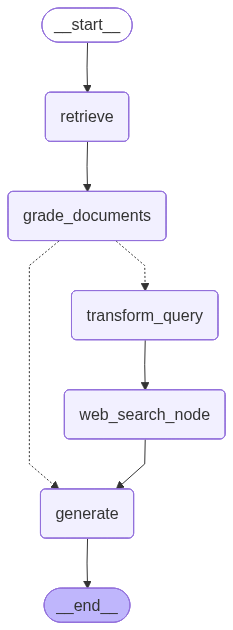

In [232]:
app

In [178]:
from pprint import pprint

# Run
inputs = {"question": "What are the types of prompt engineering?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('The context provided mentions two basic approaches for prompting the model: '
 '**Zero-shot learning** and **Few-shot learning**. Zero-shot learning '
 'involves feeding the task text to the model and asking for results without '
 'any examples, while few-shot learning includes providing a few examples to '
 "guide the model's response. These are the primary types discussed in the "
 'given context.')


In [233]:
from pprint import pprint

# Run
inputs = {"question": "What are Tree of thought prompting ?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
"Node 'web_search_node':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('The "Tree of Thought" (ToT) prompting technique extends Chain-of-Thought '
 '(CoT) by exploring multiple reasoning possibilities at each step, '
 'decomposing problems into multiple thought steps, and generating multiple '
 'thoughts per step to create a tree structure. This approach allows for '
 'either Breadth-First Search (BFS) or Depth-First Search (DFS) exploration, '
 'with each state evaluated by a classifier or majority vote, enhancing '
 'problem-solving and reasoning